[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MahkameSalimi/ISPRS-Tutorial/blob/main/qlstm_case_study/QLSTM.ipynb)

# Quantum Machine Learning for Earth Observation Time-Series Forecasting

This tutorial applies a quantum machine learning workflow to forecast Normalized Difference Vegetation Index (NDVI) from Earth observation time series. We begin by introducing the study region, fused raster dataset, and exploratory visualizations. We then introduce the modelling concepts used throughout the workflow, starting with variational quantum circuits and a quantum model. From there, we prepare the time series through normalization and sliding windows, define the quantum circuit template, and train the model on a small chronological subset for demonstration. The tutorial then shows how one trained quantum circuit can be transpiled for execution on quantum hardware and incorporated back into the model inference workflow. Finally, we use pre-trained quantum and classical models for full-series inference, compare their performance, and conclude with directions for further exploration.

### Running the Notebook

Before beginning the workflow, make sure the notebook is running with the supporting tutorial files and required Python packages available. The notebook can be run either locally or in Google Colab.

For local execution, it is assumed that the repository has already been cloned and that the notebook is opened from its own directory.

For Google Colab, the setup cell below detects whether the notebook is running in Colab, clones the repository, and moves into the tutorial directory before continuing.

The directory includes `requirements.txt` for local setup and `requirements-colab.txt` for Google Colab. Depending on your Python environment, additional Python packages may still be required.

In [ ]:
import importlib.util
import sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    repo_path = Path("/content/ISPRS-Tutorial")

    if not repo_path.exists():
        !git clone https://github.com/MahkameSalimi/ISPRS-Tutorial.git

    %cd /content/ISPRS-Tutorial/qlstm_case_study
    %pip install -q -r requirements-colab.txt

# Ensure the directory is on Python path
sys.path.insert(0, str(Path.cwd()))

print("Running in Colab:", IN_COLAB)

In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window
import geopandas as gpd

from utils.display import show_map

### Data Exploration: Features and Time series exploration

We begin by loading the study region of interest (ROI), a rectangular
area in the Regina region of Saskatchewan, stored as a shapefile. The
shapefile defines the spatial boundary of the area.

In [ ]:
TUTORIAL_DIR = Path.cwd()
DATA_DIR = TUTORIAL_DIR / "Canada_ROI_dataset"

# Load the Regina SK from Canadian ROI Dataset directory 
SK_roi_path = DATA_DIR / "Regina_SK_ROI" / "ROI_Regina_Saskatchewan.shp"
SK_tif_path = DATA_DIR / "fused_regina_2010_2024.tif"
SK_roi = gpd.read_file(SK_roi_path)
SK_roi_wgs84 = SK_roi.to_crs(epsg=4326)
print(SK_roi_wgs84[["geometry"]].to_string())

We display the study region directly in the notebook. The map
`regina_sk_roi.html` is stored in the `maps` directory, and the
`show_map` helper function in `utils/display.py` loads and renders it
as an interactive cell output.


In [ ]:
show_map("regina_sk_roi.html")

We begin an exploratory look at the data structure. The fused raster
contains three features (NDVI, precipitation, and mean temperature)
recorded weekly from week 16 to week 41 (approximately mid-April to
mid-October) across 2010 to 2024. NDVI is derived from AVHRR and VIIRS satellite imagery, distributed by
Statistics Canada and climate data from Daymet. The cell below
reads the band naming convention from the GeoTIFF file, a raster format
that stores gridded spatial data alongside geographic metadata, to
confirm how features and timesteps are laid out across bands.


In [ ]:
# Each band in the TIF follows a consistent naming convention:
#   {year}_{week}_{feature}
#
# Features repeat every 3 bands, so one timestep spans 3 consecutive bands:
#   Band 1: 2010_W16_ndvi
#   Band 2: 2010_W16_prcp_mm
#   Band 3: 2010_W16_tmean_c
#   Band 4: 2010_W17_ndvi
#   ...

with rasterio.open(SK_tif_path) as src:
    sample_descs = src.descriptions[:9]  # first 3 timesteps = 9 bands

print("Band naming convention (first 9 bands = first 3 timesteps):")
for i, name in enumerate(sample_descs):
    print(f"  Band {i+1}: {name}")

We inspect the global properties of the dataset, including the spatial
grid dimensions, available features, and temporal coverage, to confirm
the data loaded as expected.


In [ ]:
with rasterio.open(SK_tif_path) as src:
    descs = src.descriptions
    n_bands = src.count
    height, width = src.height, src.width

n_features = 3
feature_names = ["NDVI", "Precipitation (mm)", "Mean Temperature (°C)"]
T = n_bands // n_features

# Extract unique timestep labels by taking every n_features-th band description, e.g. "2010_W16"
timestep_labels = [d.rsplit("_", 1)[0] for d in descs[::n_features]]  
years = sorted(set(lbl.split("_")[0] for lbl in timestep_labels))

print(f"Spatial grid   : {height} rows x {width} cols ({height * width} pixels total)")
print(f"Features       : {', '.join(feature_names)}")
print(f"Temporal range : {timestep_labels[0]} to {timestep_labels[-1]}")
print(f"Weeks covered  : W16 to W41 (26 weeks/year)")
print(f"Years          : {years[0]} to {years[-1]} ({len(years)} years)")
print(f"Total timesteps: {T} ({len(years)} years x 26 weeks)")

We extract the timeseries of the center pixel as a working example
and inspect its first few timesteps and summary statistics.


In [ ]:
# Extract the center pixel timeseries for all 3 features
with rasterio.open(SK_tif_path) as src:
    # Center pixel
    row, col = src.height // 2, src.width // 2
    # Window reads a 1x1 spatial tile at the selected pixel position
    window = Window(col_off=col, row_off=row, width=1, height=1)

    # src.read returns shape (n_bands, 1, 1)
    # flatten gives a 1-D array of length n_bands
    pixel_data = src.read(window=window).flatten()

# Bands cycle through the 3 features at each timestep: [ndvi_t0, prcp_t0, temp_t0, ndvi_t1, ...]
# reshape(T, n_features) folds this into rows of timesteps and columns of features
pixel_matrix = pixel_data.reshape(T, n_features)

df = pd.DataFrame(pixel_matrix, columns=feature_names, index=timestep_labels)
df.index.name = "Timestep"

print(f"Center pixel: row={row}, col={col}")
print(f"\nFirst 5 timesteps:")
print(df.head())
print(f"\nBasic statistics:")
print(df.describe().round(3))

We plot the three feature timeseries for the center pixel across 2010 to 2024 record. Each panel shows one feature, with the
x-axis ticked at the start of each year. The seasonal pattern of NDVI
is visible as a recurring peak during the growing season, while
precipitation and temperature follow their own annual cycles.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colors = ["#2d8a4e", "#1f77b4", "#d62728"]

for i, (feat, color) in enumerate(zip(feature_names, colors)):
    axes[i].plot(df.index, df[feat], color=color, linewidth=0.9)
    axes[i].set_ylabel(feat, fontsize=10)
    axes[i].grid(True, alpha=0.3)

# Tick at the first timestep of each new year
label_years = [lbl.split("_")[0] for lbl in df.index]
year_ticks = [df.index[i] for i in range(len(label_years))
              if i == 0 or label_years[i] != label_years[i - 1]]

axes[-1].set_xticks(year_ticks)
axes[-1].set_xticklabels(
    [lbl.split("_")[0] for lbl in year_ticks],
    rotation=45,
    fontsize=9,
)
axes[-1].set_xlabel("Year  (each year spans weeks W16 to W41)", fontsize=10)

fig.suptitle("Regina, SK - Center Pixel Feature Timeseries (2010-2024, W16-W41)", fontsize=13)
plt.tight_layout()
plt.show()

### Variational Quantum Circuits

A variational quantum circuit (VQC), also called a parameterized quantum circuit (PQC), is a quantum circuit whose gates contain tunable parameters. We can write such a circuit as

$$
U(\boldsymbol{x}, \boldsymbol{\theta}),
$$

where $\boldsymbol{x}$ represents input-dependent encoding angles and $\boldsymbol{\theta}$ represents trainable circuit parameters.


<div align="center">
  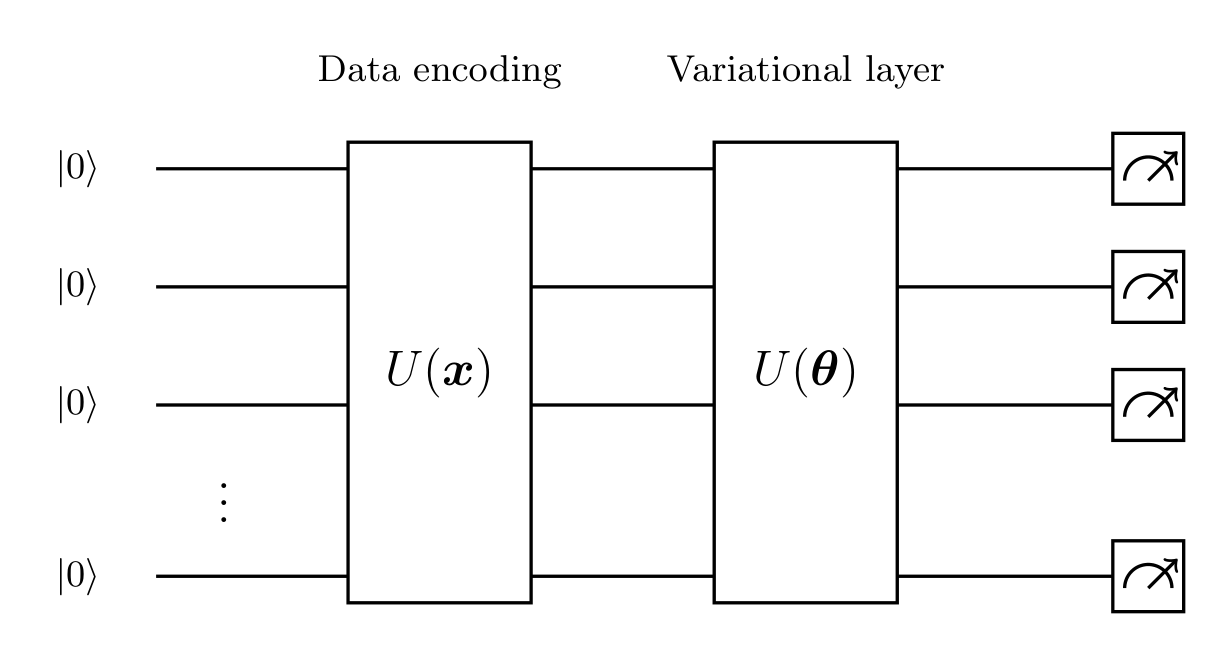
</div>



After running the circuit, we measure expectation values. For qubit $j$, the Pauli-Z expectation value can be written as

$$
\langle Z_j \rangle_{\boldsymbol{x}, \boldsymbol{\theta}}
=
\langle 0 |
U^\dagger(\boldsymbol{x}, \boldsymbol{\theta})
Z_j
U(\boldsymbol{x}, \boldsymbol{\theta})
| 0 \rangle.
$$

Here, $\boldsymbol{x}$ denotes the input encoding angles, and $\boldsymbol{\theta}$ denotes the trainable circuit parameters. The resulting expectation values are classical numbers that can be passed into the rest of a hybrid model.

This idea of a trainable circuit is used in variational quantum algorithms such as the variational quantum eigensolver (VQE). In VQE, a parameterized circuit prepares a quantum state $|\psi(\boldsymbol{\theta})\rangle$, and the objective is usually an energy expectation,

$$
E(\boldsymbol{\theta})
=
\langle \psi(\boldsymbol{\theta}) | H | \psi(\boldsymbol{\theta}) \rangle,
$$

where $H$ is a Hamiltonian. A classical optimizer updates $\boldsymbol{\theta}$ to minimize

$$
\boldsymbol{\theta}^\star
=
\arg\min_{\boldsymbol{\theta}} E(\boldsymbol{\theta}).
$$

Here, we use VQCs in a supervised learning setting. In quantum machine learning, the same trainable circuit idea can be used inside a supervised learning pipeline. The model combines quantum circuit parameters and classical neural network weights to produce predictions $\hat{y}_t$, compare them with targets $y_t$, and update trainable parameters over repeated training epochs.

The training objective can be written abstractly as

$$
(\boldsymbol{\theta}^\star, \boldsymbol{\phi}^\star)
=
\arg\min_{\boldsymbol{\theta}, \boldsymbol{\phi}}
\mathcal{L}
\left(
\{\hat{y}_t(\boldsymbol{\theta}, \boldsymbol{\phi})\}_{t=1}^{N},
\{y_t\}_{t=1}^{N}
\right),
$$

where $\boldsymbol{\theta}$ denotes the VQC parameters, $\boldsymbol{\phi}$ denotes the classical neural network parameters, and $\mathcal{L}$ is a task specific prediction loss.

The figure below shows one example of a VQC. Classical features are encoded using $R_y$ and $R_z$ rotations, after an initial Hadamard layer. The variational layer includes an entangling block followed by trainable single qubit gates. Measurements at the end produce expectation values that are passed back to the classical model.

<div align="center">
  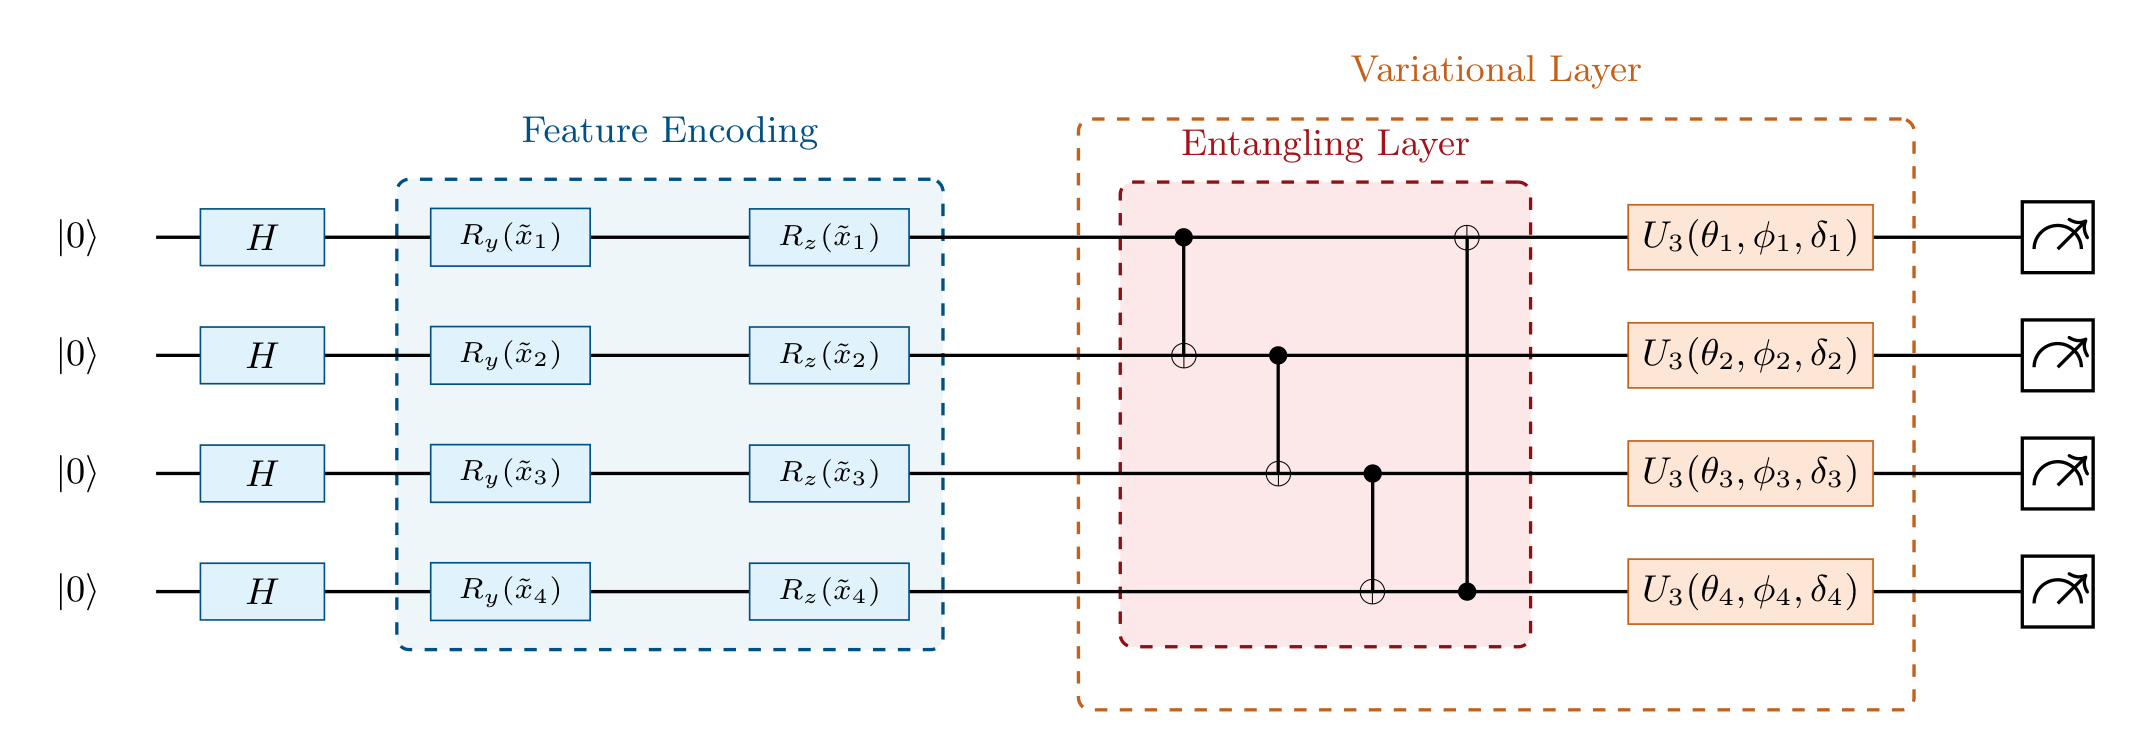
</div>


### Quantum Long Short-Term Memory

A quantum long short-term memory (QLSTM) is a hybrid quantum-classical
extension of the classical LSTM, intended for modelling time-series
data. Introduced by Samuel Yen-Chi Chen et al. in
[*Quantum Long Short-Term Memory*](https://arxiv.org/abs/2009.01783),
the QLSTM replaces gate computations inside the LSTM cell with
variational quantum circuits. Depending on design choices such as
whether classical encoders and decoders are used, how many wires are
measured, and how many VQCs are included, a QLSTM can take different
forms. In this tutorial we use a hybrid variation inspired by
[*Linear-layer-enhanced quantum long short-term memory for carbon price
forecasting*](https://link.springer.com/article/10.1007/s42484-023-00115-2).

The schematic below shows the architecture, with a shared linear
encoder feeding into four VQCs, followed by individual decoders
integrated within the classical LSTM components.


A QLSTM keeps the recurrent structure of an LSTM, but replaces part of the gate computation with VQCs. At timestep $t$, the current input $\boldsymbol{x}_t$ is combined with the previous hidden state $\boldsymbol{h}_{t-1}$,

$$
\boldsymbol{v}_t =
[
\boldsymbol{h}_{t-1},
\boldsymbol{x}_t
].
$$

Following the linear layer enhanced QLSTM idea, a classical encoder first maps this combined vector into quantum input angles,

$$
\boldsymbol{z}_t =
W_{\mathrm{enc}}\boldsymbol{v}_t + \boldsymbol{b}_{\mathrm{enc}}.
$$

The encoded vector $\boldsymbol{z}_t$ is then passed to four VQC blocks,

$$
\boldsymbol{q}^{(1)}_t = \mathrm{VQC}_1(\boldsymbol{z}_t),
\qquad
\boldsymbol{q}^{(2)}_t = \mathrm{VQC}_2(\boldsymbol{z}_t),
$$

$$
\boldsymbol{q}^{(3)}_t = \mathrm{VQC}_3(\boldsymbol{z}_t),
\qquad
\boldsymbol{q}^{(4)}_t = \mathrm{VQC}_4(\boldsymbol{z}_t).
$$

The four VQCs correspond to the four recurrent components in our implementation:

$$
\mathrm{VQC}_1 \rightarrow \text{forget},
\qquad
\mathrm{VQC}_2 \rightarrow \text{input},
\qquad
\mathrm{VQC}_3 \rightarrow \text{candidate},
\qquad
\mathrm{VQC}_4 \rightarrow \text{output}.
$$

Each VQC returns expectation values measured from the quantum circuit. Classical decoders then map these quantum outputs back into the LSTM gate values,

$$
\boldsymbol{f}_t =
\sigma(W_f \boldsymbol{q}^{(1)}_t + \boldsymbol{b}_f),
\qquad
\boldsymbol{i}_t =
\sigma(W_i \boldsymbol{q}^{(2)}_t + \boldsymbol{b}_i),
$$

$$
\tilde{\boldsymbol{c}}_t =
\tanh(W_c \boldsymbol{q}^{(3)}_t + \boldsymbol{b}_c),
\qquad
\boldsymbol{o}_t =
\sigma(W_o \boldsymbol{q}^{(4)}_t + \boldsymbol{b}_o).
$$

The cell state and hidden state are then updated using the standard LSTM recurrence,

$$
\boldsymbol{c}_t =
\boldsymbol{f}_t \odot \boldsymbol{c}_{t-1}
+
\boldsymbol{i}_t \odot \tilde{\boldsymbol{c}}_t,
$$

$$
\boldsymbol{h}_t =
\boldsymbol{o}_t \odot \tanh(\boldsymbol{c}_t).
$$

After the final timestep in the input window, the last hidden state is passed through a classical output layer to produce the prediction,

$$
\hat{y} =
W_y \boldsymbol{h}_{T} + b_y,
$$

where $T$ is the last timestep in the input window.

<div align="center">
  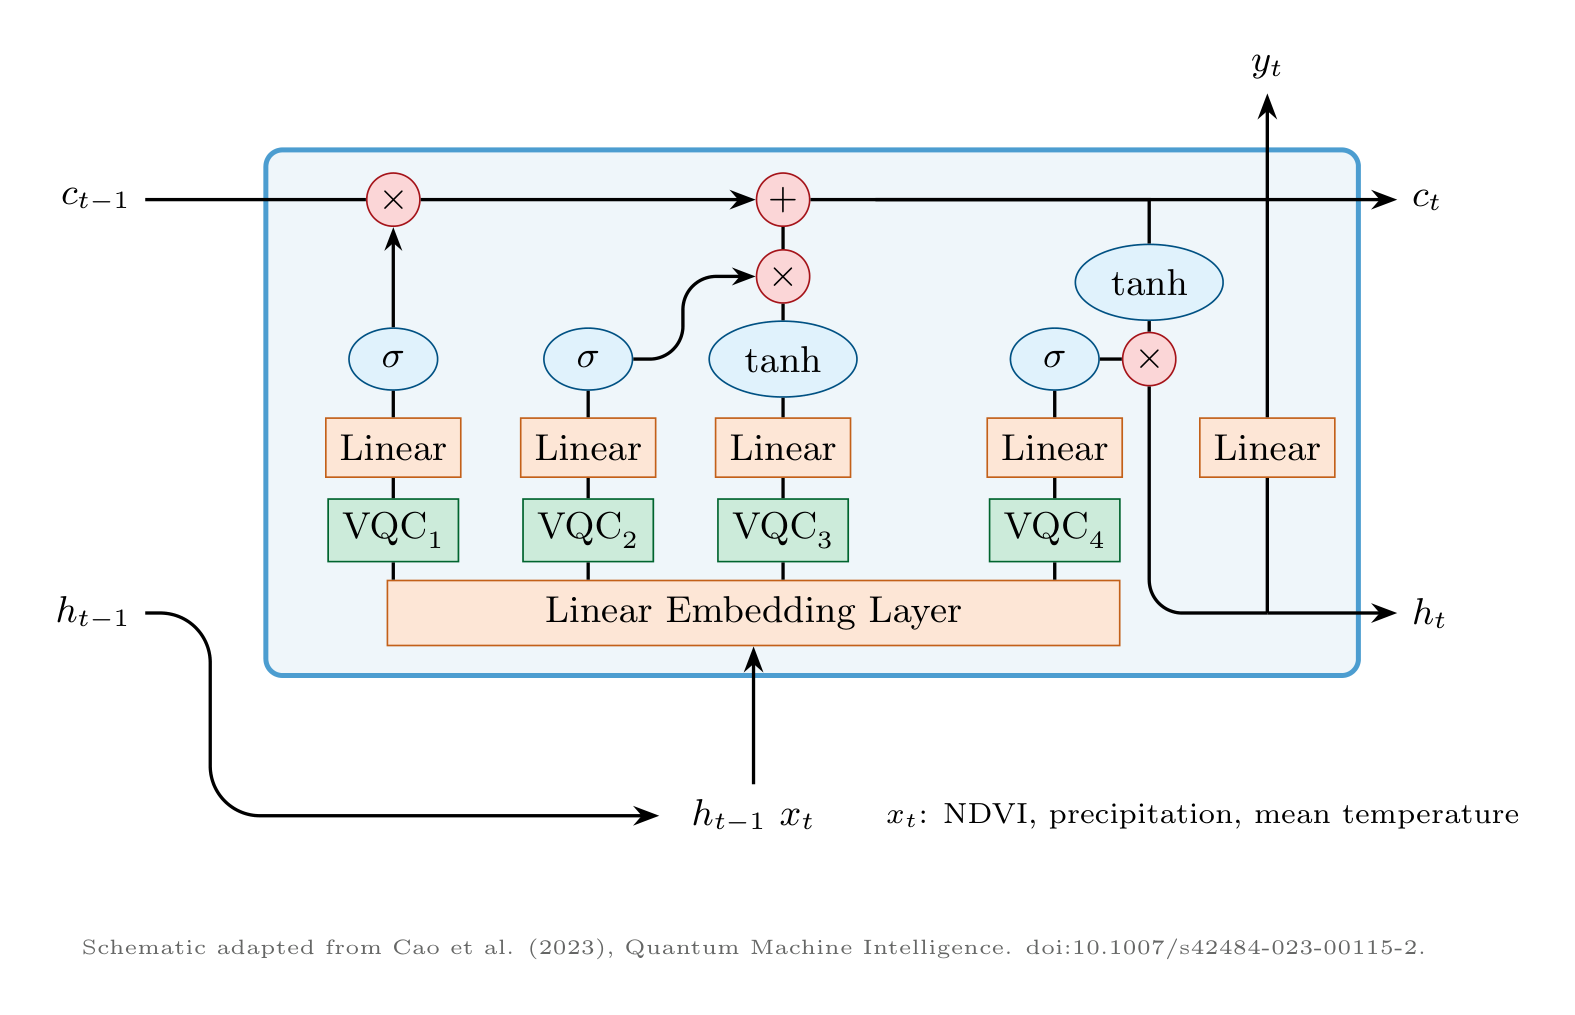
</div>


### Data Encoding and Normalization

In quantum computing and quantum machine learning, classical data needs to be encoded into quantum states. Methods of encoding include:
 - Basis encoding 
 - Amplitude encoding 
 - Angle encoding 
 - Phase encoding 
 - Dense angle encoding 

For more information, refer to [IBM's reference on data encoding](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding) and PennyLane's blog on [How to embed data into a quantum state](https://pennylane.ai/blog/2022/08/how-to-embed-data-into-a-quantum-state).

For the purposes of this notebook, we will employ angle encoding using $R_y$ and $R_z$ gates. Since these gates are $2\pi$-periodic up to a global phase, it is important to normalize features $x \mapsto \tilde{x}$ before passing them to the encoding rotational gates. We will employ a domain-informed normalization approach.

$$
\begin{aligned} 
&\text{NDVI}: [-1,1] \rightarrow [-\pi/2, \pi/2] \\
&\text{precipitation}: [0, 200] \rightarrow [0, \pi/2] \\ 
&\text{temperature}: [-50, 50] \rightarrow [-\pi/2, \pi/2] \\
\end{aligned}
$$

In [ ]:
def minmax_normalize(x, min_val, max_val, target_low, target_high):
    return target_low + (x - min_val) / (max_val - min_val) * (target_high - target_low)

PI_HALF = np.pi / 2

norm_specs = {
    "NDVI":                   dict(min_val=-1.0,  max_val=1.0,   target_low=-PI_HALF, target_high=PI_HALF),
    "Precipitation (mm)":     dict(min_val=0.0,   max_val=200.0, target_low=0.0,      target_high=PI_HALF),
    "Mean Temperature (°C)":   dict(min_val=-50.0, max_val=50.0,  target_low=-PI_HALF, target_high=PI_HALF),
}

df_norm = df.copy()
for feat, spec in norm_specs.items():
    df_norm[feat] = minmax_normalize(df[feat].values, **spec)

print("Normalized ranges:")
print(df_norm.describe().round(4))


### Time-Series Windowing

In time series modelling, raw data is sliced into fixed-length input/output samples before training. This is called sliding window segmentation. The design choices include the lookback window, which defines how far back in time the model can draw information from, the sampling pattern within that window, meaning which timesteps are actually selected and whether they are contiguous or spaced apart, the forecast horizon, which defines how far ahead the model predicts, and whether the target is one or multiple features. In this tutorial, the model draws from a lookback window of 3 contiguous timesteps and predicts a single NDVI value 4 timesteps ahead, a single-output setup.

In [ ]:
def make_windows(series, seq_len, horizon):
    """
    series : np.ndarray, shape (T, F)
    returns X of shape (N, seq_len, F) and y of shape (N,)
    """
    T, F = series.shape
    windows = sliding_window_view(series, window_shape=(seq_len, F)).squeeze()  # (N,1,seq_len,F) -> (N,seq_len,F)

    
    X = windows[:-horizon]                              # (N, seq_len, F)
    y = series[seq_len + horizon - 1:, 0]              # (N,) NDVI is column 0

    return X, y

seq_len = 3
horizon = 4

data_norm = df_norm.values  # shape (390, 3)
X, y = make_windows(data_norm, seq_len=seq_len, horizon=horizon)

print(f"X shape: {X.shape}   (samples, lookback, features)")
print(f"y shape: {y.shape}   (samples,)")
print(f"\nTotal timesteps : {len(data_norm)}")
print(f"Windows produced: {len(X)}  ({len(data_norm)} - {seq_len} - {horizon} + 1)")

In [ ]:
# Show the first 2 (X, y) pairs to illustrate the sliding window
for i in range(2):
    print(f"Sample {i+1}:")
    print(f"  X (input window, shape {X[i].shape}):")
    for t, row in enumerate(X[i]):
        label = df_norm.index[i + t]
        print(f"    t+{t}  {label}  NDVI={row[0]:.4f}  Precip={row[1]:.4f}  Temp={row[2]:.4f}")
    target_label = df_norm.index[i + seq_len + horizon - 1]
    print(f"  y (target NDVI at {target_label}): {y[i]:.4f}")


The figure below illustrates sliding window segmentation applied to the normalized NDVI timeseries of the center pixel. Each panel shows a different sample, where the highlighted points form the input window of 3 consecutive timesteps, and the red cross marks the target NDVI value located 4 timesteps ahead. The faded background shows the full timeseries for context. Samples are drawn from the beginning, middle, and end of the record to show how the window slides across the entire 2010-2024 period.

<div align="center">
  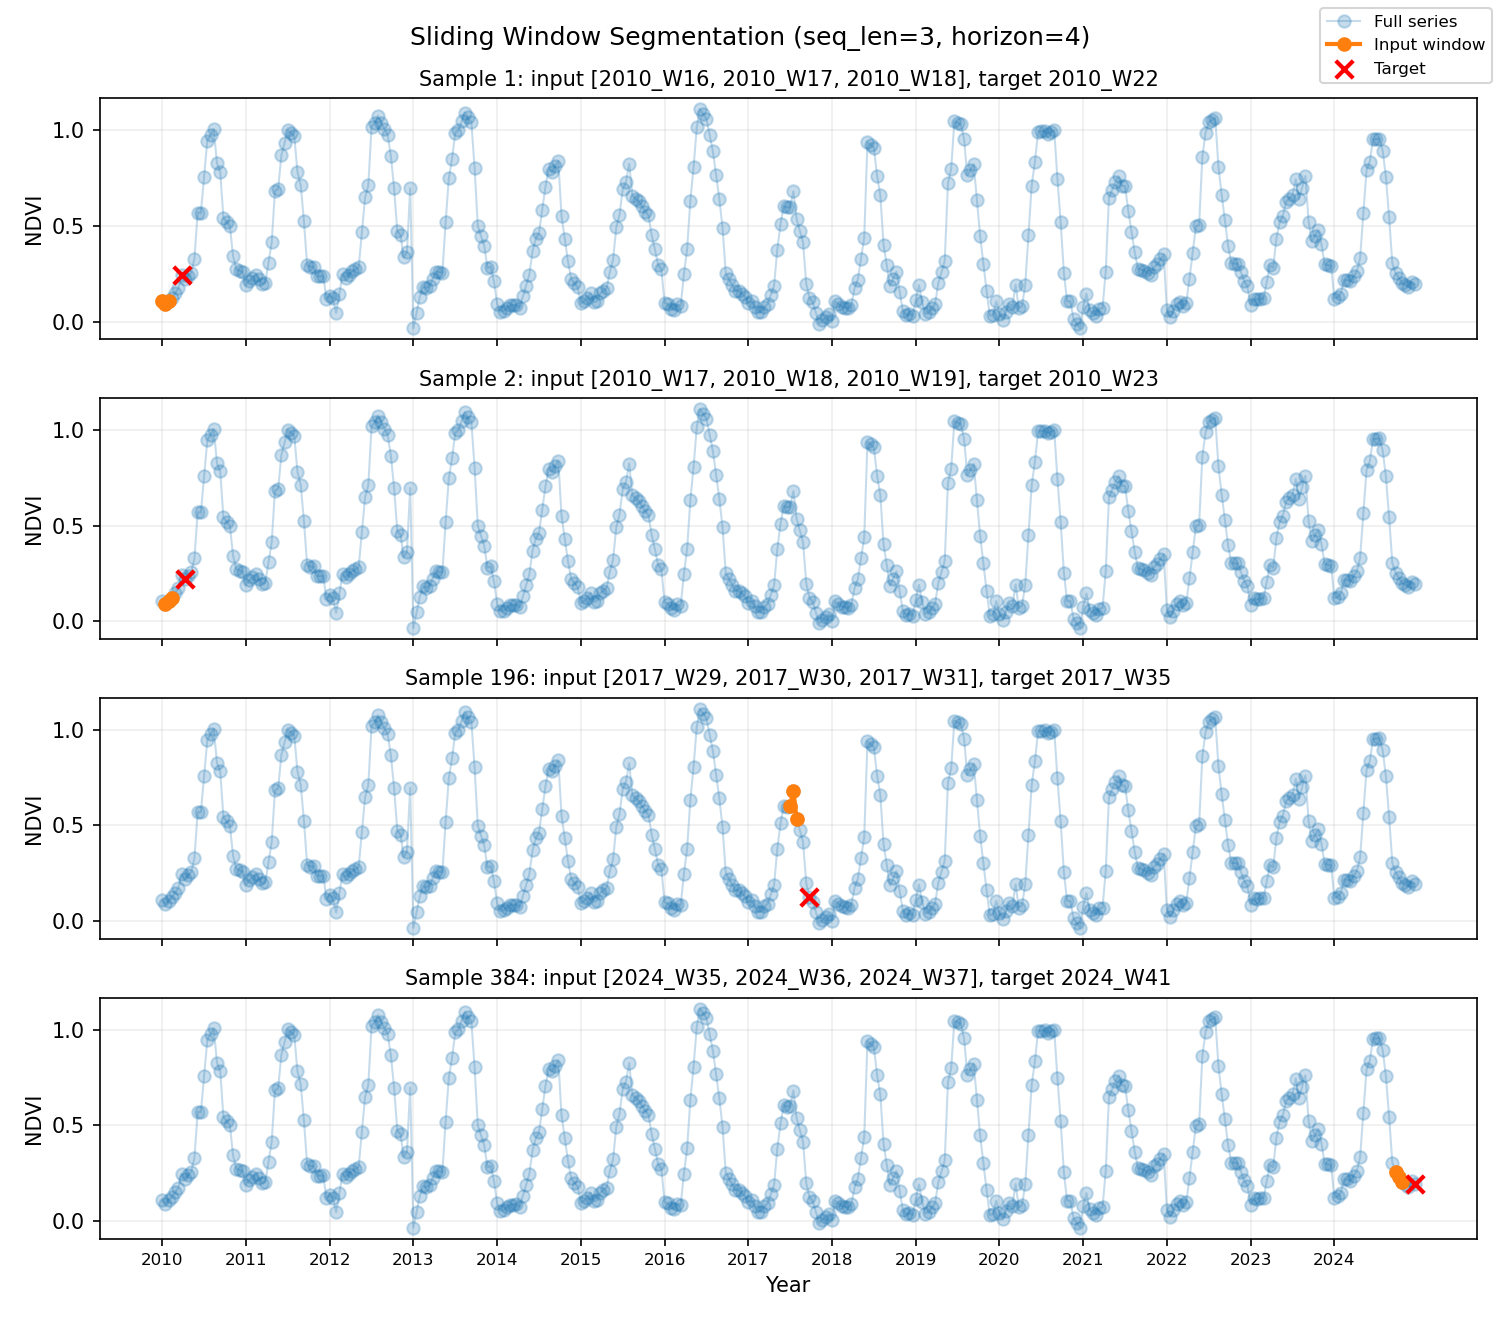
</div>


### Variational Quantum Circuit Template

For the tutorial, we define one representative VQC block. The normalized inputs are encoded with $R_y(\tilde{x}_i)$ and $R_z(\tilde{x}_i)$ rotations, the variational layer uses a ring of trainable `IsingXY` two-qubit gates followed by trainable `U3` single-qubit gates, and the block uses one reupload layer. These choices are configurable. The encoding layer can use gates such as `RX`, `RY`, or `RZ`, while the variational layer can use different single-qubit gates such as `RX`, `RY`, `RZ`, or `U3`, along with different entangling gates such as `CNOT`, `CRX`, `CRY`, `CRZ`, or Ising-type interactions.

We will use PennyLane to implement the VQC and the QLSTM. PennyLane is a
quantum software package developed by Xanadu, specialized for quantum machine
learning, and provides a variety of tools for hybrid classical and quantum
computations. In particular, through `interface` it gives the user the
flexibility to choose an interface for computing the gradients of quantum
circuits needed for training a quantum model. Supported libraries include
NumPy, PyTorch, and JAX. See `qml.math.SUPPORTED_INTERFACE_NAMES` for a list
of all accepted interface strings. We will use the PyTorch interface to
implement and train the QLSTM model. Later in the tutorial, we will export a
trained VQC from PennyLane to Qiskit and submit it as a job on IBM quantum
hardware.

Additionally, the PennyLane ecosystem treats the following three concepts
separately, while keeping them connected to each other:

 - A **quantum function** is an ordinary Python function that applies quantum
   gates and returns a measurement.
 - A **device** is a local simulator or hardware that executes the circuit.
 - A **QNode** is an object that binds a quantum function to a device,
   producing an executable quantum circuit.

We will begin by demonstrating a sample template of a VQC, which shows device
creation via `qml.device`, a quantum function via the `quantum_circuit`
function, and binding them together via the `@qml.qnode` decorator. We will
later create 4 separate QNode objects, one for each VQC in the QLSTM cell.

For a high level overview of what PennyLane is, interfaces, quantum circuits,
and quantum nodes, see the following PennyLane documentation and glossary
pages.

 - [What is PennyLane](https://docs.pennylane.ai/en/stable/introduction/pennylane.html)
 - [Interfaces](https://docs.pennylane.ai/en/stable/introduction/interfaces.html)
 - [PyTorch interface](https://docs.pennylane.ai/en/stable/introduction/interfaces/torch.html)
 - [Quantum circuits](https://docs.pennylane.ai/en/stable/introduction/circuits.html)
 - [Quantum nodes](https://pennylane.ai/glossary/quantum_node)


In [ ]:
import pennylane as qml

n_qubits = 6              
reupload_layers = 1   

vqc_dev = qml.device("default.qubit", wires=n_qubits)


def encode_features(inputs):
    """Encode normalized classical inputs as rotation angles."""
    for wire in range(n_qubits):
        qml.Hadamard(wires=wire)

    for wire in range(n_qubits):
        qml.RY(inputs[wire], wires=wire)
        qml.RZ(inputs[wire], wires=wire)


def variational_layer(layer_weights):
    """Apply one variational layer with entangling gates followed by single-qubit gates."""
    entangling_weights = layer_weights["entangling"]
    single_qubit_weights = layer_weights["single_qubit"]

    for wire in range(n_qubits):
        qml.IsingXY(entangling_weights[wire], wires=[wire, (wire + 1) % n_qubits])

    for wire in range(n_qubits):
        theta, phi, delta = single_qubit_weights[wire]
        qml.U3(theta, phi, delta, wires=wire)

@qml.qnode(vqc_dev)
def quantum_circuit(inputs, variational_weights):
    encode_features(inputs)

    for layer in range(reupload_layers):
        variational_layer(variational_weights[layer])

    return [qml.expval(qml.PauliZ(wire)) for wire in range(n_qubits)]



Before embedding this circuit into the QLSTM pipeline, we can visualize what one quantum block looks like. The following block instantiates the circuit with placeholder values, and then plots the template using PennyLane's `draw_mpl`. Reading the diagram from left to right, we can trace the application of Hadamards, followed by the $R_y/R_z$ encoding layer that loads the classical inputs, the ring of IsingXY entangling gates, and the trainable U3 single-qubit rotations. Note that the number of trainable parameters is determined by the gate choices. `CNOT` has no parameter, as it is a special case of a controlled rotation whose angle is fixed at $\pi$ up to a phase, while `RZ` has one and `U3` has three per gate. In the QLSTM, four independent copies of this template, with their own trained weights, will implement the forget, input, candidate, and output gates.

In [ ]:
# Example inputs and weights for drawing the template.
random_generator = np.random.default_rng(2026)
placeholder_inputs = np.linspace(-np.pi / 2, np.pi / 2, n_qubits)

# The number of trainable parameters depends on the gate choice.
# For example, CNOT has no trainable parameter, RZ has 1, and U3 has 3.
placeholder_weights  = [
    {
        "entangling": random_generator.uniform(0.0, 0.1, size=n_qubits),
        "single_qubit": random_generator.uniform(0.0, 0.1, size=(n_qubits, 3)),
    }
    for _ in range(reupload_layers)
]

fig, ax = qml.draw_mpl(quantum_circuit, decimals=1, style="pennylane")(
    placeholder_inputs,
    placeholder_weights 
)
plt.show()

Recall that a QNode binds a quantum function to a device. The QLSTM cell
uses four independent quantum blocks. Rather than copying the same
QNode definition four times, we wrap the construction in a factory function.
Each call to `make_qnode` returns a fresh QNode with its own device, built
from the same `encode_features` and `variational_layer` components defined
earlier.  The QNode here is created with
`interface="torch"`, so its inputs and outputs are PyTorch tensors and the
QNode behaves like a differentiable PyTorch operation. The torch interface is what allows these quantum blocks to be
embedded inside a PyTorch model alongside classical layers, so that a single
call to `loss.backward()` differentiates through the entire hybrid model and
optimizers from `torch.optim` update the classical and quantum parameters
together.


In [ ]:
def make_qnode():
    """Create a fresh QNode for one QLSTM quantum block."""
    device = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(device, interface="torch")
    def circuit(inputs, variational_weights):
        encode_features(inputs)
        for layer in range(reupload_layers):
            variational_layer(variational_weights[layer])
        return [qml.expval(qml.PauliZ(wire)) for wire in range(n_qubits)]
    return circuit

The QNode returned by `make_qnode` is an executable circuit, but it holds no
trainable parameters. The variational weights are passed in as arguments on
every call.
To make the weights trainable within PyTorch, we wrap each QNode in a small
[`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
called `VQCBlock`, which pairs the circuit with its own weights stored as
`nn.Parameter` objects. PyTorch automatically tracks every `nn.Parameter`
assigned to a module, which makes the weights visible to
`model.parameters()` and hence to the optimizer. The `forward` method runs
the circuit with the block's current weights and stacks the returned
expectation values into a single output tensor. 

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(2026)

class VQCBlock(nn.Module):
    """One trainable VQC with its own QNode and parameters."""

    def __init__(self):
        super().__init__()
        self.qnode = make_qnode()

        # Trainable circuit weights registered as nn.Parameters. 
        # See https://docs.pytorch.org/docs/stable/generated/torch.rand.html
        self.entangling_weights = nn.ParameterList()
        self.single_qubit_weights = nn.ParameterList()
        for _ in range(reupload_layers):
            self.entangling_weights.append(nn.Parameter(torch.rand(n_qubits)))
            self.single_qubit_weights.append(nn.Parameter(torch.rand(n_qubits, 3)))

    def variational_weights(self):
        # Repackage the flat parameter lists into the per-layer dict layout
        return [
            {
                "entangling": self.entangling_weights[layer],
                "single_qubit": self.single_qubit_weights[layer],
            }
            for layer in range(reupload_layers)
        ]

    def forward(self, quantum_inputs):
        # Run the circuit and stack the n_qubits expectation values
        expvals = self.qnode(quantum_inputs, self.variational_weights())
        return torch.stack(expvals).float()


### Building the QLSTM Model

We now assemble the QLSTM model. `QLSTMModel` follows the classical LSTM recurrence, with the four LSTM gate
computations delegated to four `VQCBlock`s. At each timestep, a shared linear encoder takes the previous hidden state
together with the current input and maps them to a vector of length
`n_qubits`, whose entries serve as the rotation angles of the encoding
layer in all four VQCs. Each LSTM gate then has its own linear decoder that maps the per-qubit
expectation values to the hidden state dimension, followed by the sigmoid or tanh activation. In this tutorial we set `hidden_size`
equal to `n_qubits`. The cell state and
hidden state updates are identical to a classical LSTM, and a final linear
head maps the hidden state at the last timestep to a single predicted NDVI
angle.

The input `x_batch` has shape `(batch_size, seq_len, input_size)`, matching
the windows built earlier with `seq_len` of 3 and `input_size` of 3. The
forward pass loops over timesteps, and within each timestep loops over the
samples in the batch, since each VQC executes one circuit per encoded input
vector.

In [ ]:
class QLSTMModel(nn.Module):
    """QLSTM model with four VQC blocks, one per LSTM gate."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Shared classical encoder mapping [h_prev, x_t] to one rotation angle per qubit
        self.encoder = nn.Linear(input_size + hidden_size, n_qubits)

        # Four quantum blocks, one per LSTM gate
        self.vqc_forget = VQCBlock()
        self.vqc_input = VQCBlock()
        self.vqc_candidate = VQCBlock()
        self.vqc_output = VQCBlock()

        # Per-LSTM-gate classical decoders mapping per-qubit expvals to hidden_size
        self.forget_decoder = nn.Linear(n_qubits, hidden_size)
        self.input_decoder = nn.Linear(n_qubits, hidden_size)
        self.candidate_decoder = nn.Linear(n_qubits, hidden_size)
        self.output_decoder = nn.Linear(n_qubits, hidden_size)

        # Maps the hidden state to the single NDVI prediction
        self.output_head = nn.Linear(hidden_size, 1)

    def step(self, x_t, h_prev, c_prev):
        """One recurrent timestep for a single sample."""
        # Encode previous hidden state and current input into circuit angles
        combined = torch.cat([h_prev, x_t], dim=-1)
        quantum_inputs = self.encoder(combined).squeeze(0)

        # Run the four VQCs on the same encoded input
        forget_q = self.vqc_forget(quantum_inputs).unsqueeze(0)
        input_q = self.vqc_input(quantum_inputs).unsqueeze(0)
        candidate_q = self.vqc_candidate(quantum_inputs).unsqueeze(0)
        output_q = self.vqc_output(quantum_inputs).unsqueeze(0)

        # Decode expectation values into the LSTM gate activations
        forget_gate = torch.sigmoid(self.forget_decoder(forget_q))
        input_gate = torch.sigmoid(self.input_decoder(input_q))
        candidate_gate = torch.tanh(self.candidate_decoder(candidate_q))
        output_gate = torch.sigmoid(self.output_decoder(output_q))

        # Standard LSTM cell and hidden state updates
        c_t = forget_gate * c_prev + input_gate * candidate_gate
        h_t = output_gate * torch.tanh(c_t)
        y_t = self.output_head(h_t)

        return h_t, c_t, y_t

    def forward(self, x_batch):
        # x_batch shape (batch_size, seq_len, input_size)
        batch_size, seq_len, _ = x_batch.shape
        device = x_batch.device
        dtype = x_batch.dtype

        # Initial hidden and cell states
        h_t = torch.zeros(batch_size, self.hidden_size, device=device, dtype=dtype)
        c_t = torch.zeros(batch_size, self.hidden_size, device=device, dtype=dtype)

        y_t = None
        for t in range(seq_len):
            x_t = x_batch[:, t, :]

            # Each VQC runs one circuit per sample
            h_next, c_next, y_next = [], [], []
            for b in range(batch_size):
                h_b, c_b, y_b = self.step(x_t[b:b + 1], h_t[b:b + 1], c_t[b:b + 1])
                h_next.append(h_b)
                c_next.append(c_b)
                y_next.append(y_b)

            h_t = torch.cat(h_next, dim=0)
            c_t = torch.cat(c_next, dim=0)
            y_t = torch.cat(y_next, dim=0)

        # Prediction from the final timestep only
        return y_t


### Demonstration Training Subset

We now prepare the dataset for a quick live demonstration. Keep in mind that
the cost of simulating a quantum circuit on a classical machine grows
exponentially with the number of qubits. Even algorithms with a modest
number of qubits can be challenging to simulate, and at around the 50 to 60
qubit range, assuming non-trivial quantum gates, classical simulation
becomes infeasible altogether. See IonQ's blog on
[the value of classical quantum simulators](https://www.ionq.com/resources/the-value-of-classical-quantum-simulators)
for more details. Our circuits use only 6 qubits, so each individual
execution is cheap, but training involves a very large number of
executions. Every timestep of every sample runs four VQCs, and every epoch
repeats this across the training set, so training on the entire dataset for
many epochs may take minutes to hours. For this reason we take a small
chronological subset of the dataset, the first two years, and train for a
few epochs. The goal is to build intuition for how training a quantum model
behaves, and we encourage you to train on the entire dataset on your own
time.

The cell below applies the sliding window to the subset and divides the
resulting windows chronologically into a 70/15/15 train, validation, and
test split, giving 32 training, 6 validation, and 8 test windows. These
counts are far too small to support any meaningful assessment of model
performance. The purpose is purely to demonstrate the mechanics of
training. Later in the notebook we will load a model trained on the full
dataset and use it for inference and the hardware demonstration.

In [ ]:
# First two years of the series, 26 growing-season timesteps per year
subset_timesteps = 52
series_subset = data_norm[:subset_timesteps]

X_subset, y_subset = make_windows(series_subset, seq_len=seq_len, horizon=horizon)

# Chronological 70/15/15 split
n_total = len(X_subset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

X_train, y_train = X_subset[:n_train], y_subset[:n_train]
X_val, y_val = X_subset[n_train:n_train + n_val], y_subset[n_train:n_train + n_val]
X_test, y_test = X_subset[n_train + n_val:], y_subset[n_train + n_val:]

# Convert to float32 tensors, unsqueeze(1) shapes targets as (N, 1) to match the model output
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Train:", X_train_t.shape, y_train_t.shape)
print("Val:  ", X_val_t.shape, y_val_t.shape)
print("Test: ", X_test_t.shape, y_test_t.shape)


We now train the QLSTM on the subset using a standard PyTorch training
loop. Each epoch performs one forward pass over the entire training set followed
by a single optimizer step. After each update, the
model is evaluated under `torch.no_grad()` on both the training and
validation sets, so the two recorded losses reflect the same updated
weights.


In [ ]:
model = QLSTMModel(input_size=X_train_t.shape[-1], hidden_size=n_qubits)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_t)
    train_loss = loss_fn(train_pred, y_train_t)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_pred_eval = model(X_train_t)
        train_loss_eval = loss_fn(train_pred_eval, y_train_t)
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)
    train_losses.append(train_loss_eval.item())
    val_losses.append(val_loss.item())
    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"train loss: {train_loss_eval.item():.4f} | "
        f"val loss: {val_loss.item():.4f}"
    )

We plot the recorded training and validation losses against the epochs.
With only 32 training and 6 validation windows, the curves 
serve to illustrate the training dynamics rather than measure performance.


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o", label="Train")
plt.plot(val_losses, marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("QLSTM Training and Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The QLSTM models were trained on the full 2010 to 2024 series across the
following hyperparameters. The table below displays these hyperparameters,
including the hidden dimension, learning rate, and quantum gates.


| Hyperparameter        | Values                        |
| --------------------- | ----------------------------- |
| Hidden dimension $H$  | 3, 6                          |
| Learning rate         | 0.1, 0.01                     |
| Feature mode          | All features, NDVI only       |
| Quantum gates         | U3 + CNOT, U3 + IsingXY       |
| Reupload layers $R$   | 1, 3                          |
| Optimizer             | Nesterov                      |
| Dataset split         | 70% train, 15% val, 15% test  |
| Loss function         | Weighted MSE + correlation loss |
| Iterations            | 5 per combination             |

Each QLSTM cell requires 4 VQC evaluations at every timestep, so a single
forward pass over the 3-step lookback window runs 12 VQC evaluations per
sample, adding substantial execution time. Across all swept configurations,
training the QLSTM models for 100 epochs on a 13th Gen Intel Core i7 took on
average about 100 minutes. For this demo, we load the best performing model
trained with all three features. The best model was selected based on the
lowest RMSE on the validation set, coming from the run with the following
tunable hyperparameters
 - hidden dimension 6
 - U3 + IsingXY gates
 - 1 reupload layer

### Quantum Hardware Demonstration

We intend to execute a quantum circuit from the QLSTM pipeline on IBM quantum hardware. [Qiskit](https://www.ibm.com/quantum/qiskit) is IBM Quantum's open-source SDK for building quantum circuits and submitting jobs to IBM quantum systems. Our QLSTM model is implemented in PennyLane and wrapped inside a PyTorch model. Therefore, before submitting a circuit to IBM hardware, we need to translate the selected PennyLane QNode into a Qiskit-compatible circuit.

We use [OpenQASM](https://quantum.cloud.ibm.com/docs/en/guides/introduction-to-qasm), an open quantum assembly language for representing quantum circuits across compatible quantum software platforms. PennyLane provides [`qml.to_openqasm`](https://docs.pennylane.ai/en/stable/code/api/pennylane.to_openqasm.html), which exports a QNode as an OpenQASM string. Qiskit can then parse this string using [`QuantumCircuit.from_qasm_str`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit), producing a Qiskit `QuantumCircuit` that can be measured, transpiled, and submitted through Qiskit Runtime. [Qiskit Runtime](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/runtime-service) is IBM Quantum's cloud execution service for running circuits on IBM quantum systems.


In [ ]:
trained_models_dir = Path("trained_models")
qlstm_model_path = trained_models_dir / "qlstm_regina_trained.pt"

trained_qlstm_model = QLSTMModel(input_size=X.shape[-1], hidden_size=n_qubits)
trained_qlstm_model.load_state_dict(torch.load(qlstm_model_path, map_location="cpu"))

# Switches off training-only behaviour
trained_qlstm_model.eval();


We define a helper function to detach the trained variational parameters from a VQC block. The corresponding QNode is accessible through the block's `.qnode` attribute, for example `trained_qlstm_model.vqc_output.qnode`, and `qml.to_openqasm` uses that QNode together with the assigned input values and detached parameters to produce the OpenQASM string. In the QLSTM workflow, VQC input values are computed from the current timestep and the hidden state from previous timesteps. For this Qiskit circuit demonstration, we assign placeholder values and leave the actual QLSTM-derived values for the inference workflow.

In [ ]:
from qiskit import QuantumCircuit

def detach_variational_weights(block):
    return [
        {
            "entangling": layer_weights["entangling"].detach().cpu(),
            "single_qubit": layer_weights["single_qubit"].detach().cpu(),
        }
        for layer_weights in block.variational_weights()
    ]

placeholder_vqc_inputs = torch.linspace(-np.pi / 2, np.pi / 2, steps=n_qubits,dtype=torch.float32)

# Choose one trained VQC block: vqc_forget, vqc_input, vqc_candidate, or vqc_output.
selected_vqc_block = trained_qlstm_model.vqc_output

# qml.to_openqasm returns an exporter function for the selected PennyLane QNode.
qasm_exporter = qml.to_openqasm(selected_vqc_block.qnode)

# Extract the trained variational parameters for the selected VQC block.
vqc_weights = detach_variational_weights(selected_vqc_block)

# Assign input values and trained weights to produce an OpenQASM string.
vqc_output_qasm = qasm_exporter(placeholder_vqc_inputs, vqc_weights)

# Parse the OpenQASM string into a Qiskit QuantumCircuit.
vqc_output_circuit = QuantumCircuit.from_qasm_str(vqc_output_qasm)

We can check that the Qiskit circuit translated from OpenQASM produces expectation values that match the original PennyLane QNode. PennyLane executes the original QNode on `default.qubit`, which computes ideal analytic expectation values when no finite shot count is specified. On the Qiskit side, we can use local statevector-based [primitives](https://quantum.cloud.ibm.com/docs/en/api/qiskit/primitives) such as `StatevectorSampler` and `StatevectorEstimator`. These simulate the circuit by tracking the full quantum state as a $2^n$-dimensional complex vector. 

Here, we use `StatevectorSampler`. We run the circuit for a finite number of shots, collect bitstring counts, convert those counts into expectation values, and compare them against the PennyLane reference. Measurement in the computational basis returns one classical `0` or `1` from each qubit, so one shot of our 6-qubit circuit produces a 6-bit string such as `010101`; the count is the number of shots that produced that same bitstring. 

The sampler gives counts for binary measurement outcomes. These counts can be mapped to expectation values. For qubit $i$,

$$
\langle Z_i \rangle =
\frac{N_i(0) - N_i(1)}{N_{\text{shots}}},
$$

where $N_i(0)$ is the number of shots in which qubit $i$ was measured as 0, $N_i(1)$ is the number of shots in which qubit $i$ was measured as 1, and $N_{\text{shots}}$ is the total number of circuit executions.

If all shots measure qubit $i$ as 0, then $\langle Z_i \rangle = +1$. If all shots measure it as 1, then $\langle Z_i \rangle = -1$. If both outcomes occur equally often, then $\langle Z_i \rangle = 0$.

We define a helper function to convert the bitstring outcomes into expectation values.

In [ ]:
def sampler_expvals_from_counts(counts, n_qubits):
    expvals = np.zeros(n_qubits, dtype=float)
    total_shots = sum(counts.values())

    for bitstring, count in counts.items():

        # `n_qubits` can also be inferred from the length of the measured bitstrings
        for wire in range(n_qubits):
            # Align Qiskit's displayed bit order with PennyLane wire indexing
            # Store results in PennyLane wire order: expvals[0] is wire 0.
            # Qiskit displays qubit 0 on the right, so wire 0 uses bitstring[-1].
            # https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering
            bit = bitstring[-1 - wire]

            # Convert each measured bit to its Pauli-Z score and weight by its count.
            z_value = 1.0 if bit == "0" else -1.0
            expvals[wire] += count * z_value

    return expvals / total_shots


Now we compute the expectation values for this one circuit using PennyLane's analytic simulation and Qiskit's finite-shot sampler.

In [ ]:
from qiskit.primitives import StatevectorSampler

shots = 10000

# Execute the selected PennyLane VQC
pennylane_expvals = selected_vqc_block.qnode(
    placeholder_vqc_inputs,
    vqc_weights,
)

# Convert a NumPy array for comparison.
pennylane_expvals = np.asarray([
    value.detach().cpu().item() for value in pennylane_expvals
])


# Create a local sampler with a fixed number of shots
local_sampler = StatevectorSampler(default_shots=shots)

# Submit the Qiskit circuit to the local sampler
local_sampler_job = local_sampler.run([vqc_output_circuit])

# Retrieve the first circuit result
local_sampler_result = local_sampler_job.result()[0]

# Read bitstring counts from the classical register.
local_counts = local_sampler_result.data.c.get_counts()

# Convert bitstring counts into one Z expectation value per qubit
local_qiskit_expvals = sampler_expvals_from_counts(local_counts, n_qubits)


print("PennyLane expvals:")
print(pennylane_expvals)

print("\nQiskit sampler expvals:")
print(local_qiskit_expvals)

print("\nAbsolute difference:")
print(np.abs(local_qiskit_expvals - pennylane_expvals))

The results show reasonable agreement between PennyLane's analytic statevector simulation and Qiskit's finite-shot sampler. The small differences are expected because the Qiskit sampler estimates expectation values from a finite number of measurement shots.

Next, we use the trained QLSTM model to predict the first target point in the dataset, while executing only the final VQC of the final timestep on IBM quantum hardware. Before submitting that circuit, we need a few setup steps: connect to Qiskit Runtime, select an IBM backend, and transpile the circuit so it matches the backend's native gates and qubit connectivity.

A list of available IBM QPUs is available on the [IBM Quantum Platform](https://quantum.cloud.ibm.com/computers). The QPUs you can access may differ depending on your account and service instance.

To save your IBM Quantum account credentials, see IBM's guide on [saving credentials](https://quantum.cloud.ibm.com/docs/en/guides/save-credentials). The template below shows the one-time setup pattern. Replace the placeholders with your own account values. Treat your API token like a password and keep it private. Do not share it in public notebooks or code.

```python
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="API_TOKEN",
    instance="SERVICE_INSTANCE_CRN", # CRN = Cloud Resource Name
    name="isprs2026",                # Local nickname for this saved account.
    set_as_default=True,             # Use this account when no name is specified.
    overwrite=True,                  # Replace an existing saved account with this name.
)
```

You can also instantiate `QiskitRuntimeService` directly with your token and instance values instead of saving them.

```python
QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="API_TOKEN",
    instance="SERVICE_INSTANCE_CRN",
)
```

We now connect to Qiskit Runtime and select the least busy non simulator backend available to the saved account. If no live backend can be selected, we use a local fake backend so the transpilation workflow can still be demonstrated. Fake backends are local backend models provided by `qiskit_ibm_runtime.fake_provider`. For more information and a list of available fake backends, see the [IBM Quantum fake provider documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider).

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeCasablancaV2

# Set to True to use a local fake backend. False attempts IBM hardware access.
force_fake_backend = False

try:
    if force_fake_backend:
        raise RuntimeError("Testing FakeCasablancaV2 fallback.")
    
    # Assumes credentials were saved with name="isprs2026". Omit or change if needed.
    service = QiskitRuntimeService(name="isprs2026")

    # Alternative: pass credentials directly instead of using a saved account.
    #  service = QiskitRuntimeService(
    #  channel="ibm_quantum_platform",
    #  token="API_TOKEN",
    #  instance = 'SERVICE_INSTANCE_CRN',
    # )


    backend = service.least_busy(
        simulator=False,
        operational=True,
        min_num_qubits=n_qubits,
        filters=lambda backend: backend.processor_type["family"] != "Nighthawk",
    )

    using_fake_backend = False

    print("IBM Runtime connection successful.")
    print("Selected IBM backend:", backend.name)
    print("Processor family:", backend.processor_type["family"])
    print("Pending jobs:", backend.status().pending_jobs)

except Exception as exc:
    backend = FakeCasablancaV2()
    using_fake_backend = True

    print("Could not connect to IBM Runtime or select a live backend.")
    print("Using local fake backend instead:", backend.name)
    print("Reason:", type(exc).__name__, exc)

Before a circuit can run on a real IBM backend, Qiskit needs to adapt it to the backend's instruction set and qubit connectivity. This compilation step is called transpilation. At a high level, Qiskit's transpiler chooses a layout that maps the circuit's logical qubits to physical qubits, routes two-qubit operations through the backend connectivity, translates gates into the backend's native gate set, and applies circuit optimizations. See IBM's [Introduction to transpilation](https://quantum.cloud.ibm.com/docs/en/guides/transpile), [Transpilation default settings and configuration options](https://quantum.cloud.ibm.com/docs/en/guides/defaults-and-configuration-options), and [Transpiler stages](https://quantum.cloud.ibm.com/docs/en/guides/transpiler-stages) for more information.

Qiskit organizes these transformations into passes. A pass manager is the object that runs a sequence of these passes. The function [`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_preset) creates one of Qiskit's standard transpilation pipelines for a chosen backend and optimization level. The transpiled circuit is usually called an ISA circuit, where ISA stands for Instruction Set Architecture. See IBM's Qiskit blog post on [ISA circuits](https://www.ibm.com/quantum/blog/isa-circuits).

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pass_manager = generate_preset_pass_manager(backend=backend,optimization_level=2)

# Transpile the VQC output circuit for the selected backend; this does not execute it.
isa_vqc_output_circuit = pass_manager.run(vqc_output_circuit)

# Gate counts before transpilation.
print("Original circuit:")
print(vqc_output_circuit.count_ops())

# Gate counts after adapting the circuit to the selected backend.
print("\nTranspiled circuit:")
print(isa_vqc_output_circuit.count_ops())

We can also visually inspect the circuit before and after transpilation.

In [ ]:
print("\nOriginal circuit:")
display(vqc_output_circuit.draw(output="mpl", fold=-1))

print("\nTranspiled circuit:")
display(isa_vqc_output_circuit.draw(output="mpl", fold=-1))

We now prepare one precomputed VQC circuit from the trained QLSTM model for execution on a quantum backend. The `trained_models` directory includes QASM files for all 12 VQC calls associated with the first prediction window. There are 12 circuits because each window contains three timesteps and each QLSTM cell contains four VQCs for the forget, input, candidate, and output components.

The filenames follow the pattern `window_{window_index}_timestep_{timestep_index}_{vqc_name}_vqc.qasm`, which identifies the corresponding QLSTM call. Here, we select the output VQC at the final timestep of the first window, stored as `window_000_timestep_002_output_vqc.qasm`.

The QASM file already contains the trained VQC parameters and the input data produced for this specific QLSTM call. We load it as a Qiskit `QuantumCircuit`, then transpile it for the selected backend. 

The printed summary records the selected window, timestep, and VQC component, along with the QASM filename, total operation count, and circuit depth before and after transpilation. The input window is also prepared here because it will later be used to insert the measured VQC output back into the QLSTM prediction workflow.

In [ ]:
# Select the first input window and its final output VQC.
selected_window_index = 0
target_timestep = seq_len - 1
target_block = "output"

# Keep this window for the QLSTM prediction step.
x_window = torch.tensor(
    X[selected_window_index:selected_window_index + 1],
    dtype=torch.float32,
)

# Build the filename shared by the precomputed VQC files
selected_vqc_stem = (
    f"window_{selected_window_index:03d}_"
    f"timestep_{target_timestep:03d}_"
    f"{target_block}_vqc"
)
output_vqc_qasm_path = trained_models_dir / f"{selected_vqc_stem}.qasm"

# Load and transpile the saved QASM circuit for the selected VQC
output_vqc_qasm = output_vqc_qasm_path.read_text(encoding="utf-8")
output_vqc_circuit = QuantumCircuit.from_qasm_str(output_vqc_qasm)

isa_output_vqc_circuit = pass_manager.run(output_vqc_circuit)

# Summarize the selected VQC and its transpiled version.
print("Loaded target QLSTM VQC circuit")
print(f"Window index : {selected_window_index}")
print(f"Timestep     : {target_timestep}")
print(f"Block        : {target_block}")
print(f"QASM file    : {output_vqc_qasm_path.name}")

print("\nOriginal target circuit:")
print("Total operations:", output_vqc_circuit.size())
print("Circuit depth:", output_vqc_circuit.depth())

print("\nBackend-compatible target circuit:")
print("Total operations:", isa_output_vqc_circuit.size())
print("Circuit depth:", isa_output_vqc_circuit.depth())

We are now prepared to submit the quantum circuit to quantum hardware through Qiskit Runtime using the Sampler primitive with `shots = 1000`. Increasing the number of shots gives a more reliable estimate of the distribution produced by the noisy hardware circuit.

A good practice when submitting Qiskit Runtime jobs is to include job tags. Tags provide descriptive labels for executed circuits and make it easier to retrieve and organize jobs later. Depending on the workflow, tags can include details such as the project name, circuit type, transpilation or resilience settings, or circuit number in an iterative workflow. These are only examples, and you can choose tags that support your own organization and retrieval needs. See IBM's guide on [job tags](https://quantum.cloud.ibm.com/docs/en/guides/add-job-tags) for more information. Qiskit Runtime also retains job timing and usage information, which can be retrieved from the Runtime job object through its `metrics()` method. A Runtime job object is returned when `Sampler` or `Estimator` submits a job, or it can be retrieved later using its job ID.

```python
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
runtime_job = service.job("JOB_ID")

job_metrics = runtime_job.metrics()

print(job_metrics["timestamps"])
print(job_metrics["usage"])
```

For this live demonstration, the workflow waits for up to 10 minutes after job submission, checking the job status every 30 seconds. This waiting period includes both queue time and execution time. If the job does not finish within this period, precomputed expectation values from a previous hardware execution of the same circuit are loaded instead. When the Qiskit Runtime connection or backend selection does not proceed, the workflow uses the local fake backend instead. In that case, the circuit is then sampled locally with `StatevectorSampler`.

The circuit output consists of expectation values, not a prediction for the first window. These values must be incorporated back into the QLSTM cell to produce the prediction, which follows the circuit execution.

<div class="alert alert-block alert-warning">
    
*Usage estimate: 2 seconds (NOTE: This is an estimate only. Your runtime might vary.)*
</div>

In [ ]:
# Configure sampling and the maximum wait time
shots = 1000
timeout_seconds = 10 * 60
poll_interval_seconds = 30


if not using_fake_backend:
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    # Create job tags for identification and retrieval
    job_tags = [
        "QLSTM",
        "ISPRS_tutorial",
        "single_sampler_job",
        "final_timestep_output_vqc",
    ]

    print("Submitting selected circuit to IBM Runtime Sampler.")

    # Configure the IBM Runtime Sampler
    sampler = Sampler(
        mode=backend,
        options={
            "default_shots": shots,
            "environment": {
                "job_tags": job_tags,
            },
        },
    )

    # Submit the transpiled circuit as an IBM Runtime job
    sampler_job = sampler.run([isa_output_vqc_circuit])

    print("Submitted hardware job.")
    print("Job ID:", sampler_job.job_id())
    print("Waiting up to 10 minutes for the job to finish...")

    start_time = time.time()
    selected_vqc_expvals = None

    # Keep checking the job until it finishes or reaches the time limit
    while True:
        # Query and display the current IBM Runtime job status
        status_name = sampler_job.status()
        print("Job status:", status_name)

        if status_name == "DONE":
            # Retrieve counts and convert them to expectation values
            sampler_result = sampler_job.result()[0]
            hardware_counts = sampler_result.data.c.get_counts()
            selected_vqc_expvals = sampler_expvals_from_counts(
                hardware_counts,
                n_qubits,
            )
            print("Hardware job completed.")
            break

        # After the time limit, use the prepared hardware result and continue
        if time.time() - start_time > timeout_seconds:
            print("Hardware job did not finish within 10 minutes.")
            print("Loading saved hardware sampler result instead.")
            print("You can retrieve the live job later with job ID:", sampler_job.job_id())

            selected_vqc_expvals = np.load(
                trained_models_dir
                / f"{selected_vqc_stem}_hardware_sampler_expvals.npy"
            )
            break

        # Wait for the interval set by `poll_interval_seconds` before checking again
        time.sleep(poll_interval_seconds)

else:
    # Sample locally when the fake backend option is in use
    print("Using fake backend:", backend.name)
    print("Running the circuit locally with StatevectorSampler.")

    sampler = StatevectorSampler(default_shots=shots)
    sampler_job = sampler.run([output_vqc_circuit])
    sampler_result = sampler_job.result()[0]

    sampler_counts = sampler_result.data.c.get_counts()
    selected_vqc_expvals = sampler_expvals_from_counts(sampler_counts, n_qubits)

print("Selected VQC expectation values:")
print(selected_vqc_expvals)

While the current Python session remains active, the sampler result can be retrieved directly from `sampler_job` with `sampler_job.result()[0]`. If the Python session has been restarted or `sampler_job` has been reassigned, the same IBM Runtime job can be retrieved using its job ID.

```python
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

job_id = "JOB_ID"
retrieved_job = service.job(job_id)

print("Job ID:", retrieved_job.job_id())
print("Status:", retrieved_job.status())

retrieved_sampler_result = retrieved_job.result()[0]
retrieved_counts = retrieved_sampler_result.data.c.get_counts()

retrieved_vqc_expvals = sampler_expvals_from_counts(
    retrieved_counts,
    n_qubits,
)
```

Having obtained the expectation values for the output VQC, we can now form the forecast associated with the first input window. This requires replaying the three QLSTM cells in the window so that the recurrent hidden state and cell state are updated in sequence.

The utility function `predict_with_inserted_output_vqc` performs this replay. It runs the QLSTM workflow locally while replacing the output VQC expectation values at the selected timestep with the values obtained from the preceding circuit execution. The function receives the trained model, selected input window, VQC expectation values, and selected timestep, then returns the resulting prediction.

For comparison, we also run the same circuit with Qiskit's local `StatevectorSampler` and replay the same QLSTM workflow. This provides a local sampler reference for comparison with the expectation values obtained in the preceding step. 

We also compute the QLSTM prediction in PennyLane analytic mode with `shots=None`. In this mode, expectation values are calculated directly from the simulated quantum state rather than estimated from a finite number of shots. For further information, see PennyLane's documentation on [`shots`](https://docs.pennylane.ai/en/stable/code/api/pennylane.set_shots.html) and the [`default.qubit` simulation source](https://docs.pennylane.ai/en/stable/_modules/pennylane/devices/qubit/simulate.html).

In [ ]:
from utils.qlstm_inference import predict_with_inserted_output_vqc

# Replay the QLSTM window using the selected VQC expectation values
prediction_from_selected_expvals = predict_with_inserted_output_vqc(
    trained_qlstm_model=trained_qlstm_model,
    x_window=x_window,
    inserted_expvals=selected_vqc_expvals,
    target_timestep=target_timestep,
)

# Sample the same circuit locally for comparison
local_sampler = StatevectorSampler(default_shots=shots)
local_sampler_job = local_sampler.run([output_vqc_circuit])
local_sampler_result = local_sampler_job.result()[0]

# Convert local sampler counts into expectation values
local_sampler_counts = local_sampler_result.data.c.get_counts()
local_sampler_expvals = sampler_expvals_from_counts(local_sampler_counts, n_qubits)

# Replay the QLSTM window using local sampler expectation values
prediction_from_local_sampler_expvals = predict_with_inserted_output_vqc(
    trained_qlstm_model=trained_qlstm_model,
    x_window=x_window,
    inserted_expvals=local_sampler_expvals,
    target_timestep=target_timestep,
)

# Evaluate the selected window with analytic PennyLane expectation values
with torch.no_grad():
    analytic_prediction = trained_qlstm_model(x_window).squeeze().item()

Note that due to the normalization performed earlier, which maps NDVI
from $[-1,1] \rightarrow [-\frac{\pi}{2}, \frac{\pi}{2}]$, the model
predictions are in the normalized range and do not correspond to
physical NDVI values directly. The `decode_ndvi` function reverses this
mapping to recover the original NDVI scale.


In [ ]:
def decode_ndvi(encoded_value):
    return encoded_value / (np.pi / 2)



We then decode the observed target and the model predictions from analytic simulation, local sampling, and the runtime sampling to NDVI scale.

In [ ]:
observed_ndvi = decode_ndvi(float(y[selected_window_index]))
analytic_ndvi = decode_ndvi(analytic_prediction)
local_sampler_ndvi = decode_ndvi(prediction_from_local_sampler_expvals)
runtime_ndvi = decode_ndvi(prediction_from_selected_expvals)

We visualize how the predictions compare with the observed target NDVI for this single forecast window.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

labels = ["Analytic", "Local sampler", "Runtime"]
values = [analytic_ndvi, local_sampler_ndvi, runtime_ndvi]
colors = ["forestgreen", "royalblue", "tomato"]

# Sort bars low to high and legend shows each method and its NDVI
for v, l, c in sorted(zip(values, labels, colors)):
    ax.bar(l, v, color=c, width=0.5, label=f"{l}: {float(v):.4f}")

# Observed NDVI at the forecast target timestep
ax.axhline(observed_ndvi, color="black", linestyle="--", linewidth=1.5,
           label=f"Target: {float(observed_ndvi):.4f}")

ax.set_ylabel("NDVI")
ax.set_title("Single-Window NDVI Prediction Comparison")
ax.grid(True, axis="y", alpha=0.3)
all_vals = values + [observed_ndvi]
margin = 0.3 * (max(all_vals) - min(all_vals) + 0.01)
ax.set_ylim(min(all_vals) - margin, max(all_vals) + margin)

# Legend
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### Full-Series Inference Comparison

To put the QLSTM results in context, we compare against a classical LSTM baseline trained on the same task and data split. The classical model uses the same input size, hidden size, and single-step NDVI output so the comparison stays as aligned as the architectures allow.

When comparing hybrid quantum-classical and classical models, it helps to match the task, data, evaluation metric, and capacity settings where possible. Even so, QLSTM and classical LSTM are not strictly one-to-one equivalents because the quantum blocks replace gate computations with variational circuits and expectation-value readouts. An exact like-for-like comparison is therefore not fully attainable. Comparing both models on the same metric under similar training conditions still provides a useful reference for how the QLSTM performs relative to a classical baseline.

We load the pre-trained classical LSTM checkpoint below.

In [ ]:
class ClassicalLSTM(nn.Module):
    """Classical LSTM baseline"""
    def __init__(self, input_size, hidden_size, output_dim=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.output_head = nn.Linear(hidden_size, output_dim)

    def forward(self, x_batch):
        output_sequence, _ = self.lstm(x_batch)
        h_last = output_sequence[:, -1, :]
        return self.output_head(h_last)

# Pre-trained classical baseline 
lstm_model_path = trained_models_dir / "lstm_regina_trained.pt"

classical_lstm_model  = ClassicalLSTM(input_size=X.shape[-1], hidden_size=n_qubits)
classical_lstm_model.load_state_dict(torch.load(lstm_model_path, map_location="cpu"))
classical_lstm_model.eval();


We run inference with the pre-trained QLSTM and classical LSTM models on the full time-series dataset. Predictions are returned as PyTorch tensors, converted to NumPy arrays, and mapped to physical NDVI with `decode_ndvi`.

*The inference may take about 30 seconds.*

In [ ]:
X_full_t = torch.tensor(X, dtype=torch.float32)

with torch.no_grad():
    y_pred_qlstm_full_t = trained_qlstm_model(X_full_t)
    y_pred_lstm_full_t = classical_lstm_model(X_full_t)

y_true_full_ndvi = decode_ndvi(y)
y_pred_qlstm_full_ndvi = decode_ndvi(y_pred_qlstm_full_t.squeeze(1).detach().cpu().numpy())
y_pred_lstm_full_ndvi = decode_ndvi(y_pred_lstm_full_t.squeeze(1).detach().cpu().numpy())

We compute three regression metrics for comparison. The mean
absolute error (MAE), mean squared error (MSE), and root mean squared
error (RMSE) are defined as

$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |y_i - \hat{y}_i|$$

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

These metrics measure closeness to the observed NDVI values, with lower values indicating better agreement. MAE treats all errors equally and is
robust to outliers. MSE penalizes larger errors more heavily due to the
squaring, making it more sensitive to large deviations. RMSE
shares this sensitivity but is expressed in the same units as the
target variable, making it more directly interpretable than MSE.

These metrics are also available in scikit-learn via
`mean_squared_error`, `mean_absolute_error`, and
`root_mean_squared_error`; however. we implement them directly here.

In [ ]:
qlstm_mse = np.mean((y_pred_qlstm_full_ndvi - y_true_full_ndvi) ** 2)
qlstm_rmse = np.sqrt(qlstm_mse)
qlstm_mae = np.mean(np.abs(y_pred_qlstm_full_ndvi - y_true_full_ndvi))

lstm_mse = np.mean((y_pred_lstm_full_ndvi - y_true_full_ndvi) ** 2)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = np.mean(np.abs(y_pred_lstm_full_ndvi - y_true_full_ndvi))

print("QLSTM")
print(f"  MSE : {qlstm_mse:.4f}")
print(f"  RMSE: {qlstm_rmse:.4f}")
print(f"  MAE : {qlstm_mae:.4f}")
print("Classical LSTM")
print(f"  MSE : {lstm_mse:.4f}")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE : {lstm_mae:.4f}")


We plot the observed NDVI alongside the QLSTM and classical LSTM
predictions across the full 2010 to 2024 series. The first few
timesteps appear as a dashed line because the sliding window consumes
the initial lookback and horizon before producing its first prediction.
The RMSE for each model is included in the legend for
comparison. The observed NDVI follows a repeating seasonal cycle,
rising during the growing season and falling back each year. Both
models capture this overall seasonal pattern and tend to underestimate
the peak values.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full timeseries labels and observed NDVI (decoded to physical scale)
all_labels = list(timestep_labels)
all_observed_ndvi = [decode_ndvi(float(v)) for v in data_norm[:, 0]]

# Window target labels start at seq_len + horizon - 1
offset = seq_len + horizon - 1
window_labels = [timestep_labels[offset + i] for i in range(len(y_true_full_ndvi))]

# Observed NDVI: dashed for the initial gap, solid where predictions exist
ax.plot(all_labels[:offset + 1], all_observed_ndvi[:offset + 1],
        linewidth=2, color="tab:blue", linestyle="--")
ax.plot(all_labels[offset:], all_observed_ndvi[offset:],
        linewidth=2, color="tab:blue", label="Observed NDVI")

# Plot predictions aligned to their target timesteps
ax.plot(window_labels, y_pred_qlstm_full_ndvi,
        label=f"QLSTM (RMSE: {qlstm_rmse:.4f})", linewidth=2, color="tab:orange")
ax.plot(window_labels, y_pred_lstm_full_ndvi,
        label=f"Classical LSTM (RMSE: {lstm_rmse:.4f})", linewidth=2, color="tab:green")



# Tick at the first timestep of each new year
label_years = [lbl.split("_")[0] for lbl in all_labels]
year_ticks = [all_labels[i] for i in range(len(label_years))
              if i == 0 or label_years[i] != label_years[i - 1]]

ax.set_xticks(year_ticks)
ax.set_xticklabels([lbl.split("_")[0] for lbl in year_ticks], rotation=45, fontsize=9)
ax.set_xlabel("Year (each year spans weeks W16 to W41)", fontsize=10)
ax.set_ylabel("NDVI")
ax.set_title("QLSTM vs Classical LSTM on Full NDVI Series")
ax.grid(True, alpha=0.3)


ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Summary and Next Steps

In this tutorial, we covered fundamentals of variational quantum
circuits and their role in quantum machine learning. As an application,
we implemented a QLSTM model for predicting NDVI and compared a
pre-trained QLSTM with a classical LSTM baseline.

Data for two additional regions in Canada have been included for
further exploration. Jasper, Alberta and Crawford Bay, British Columbia
offer different ecosystems with the same data structure.

In [ ]:
show_map("jasper_ab_roi.html")

In [ ]:
show_map("crawford_bc_roi.html")

To guide further exploration, consider the following.

1. The VQC template used in this tutorial is one of many possible
   designs. Try changing the gate choices, entangling structure, or
   number of reupload layers. What differences do you observe in
   model performance?

2. Explore how model performance changes with different hyperparameters such as input window length, hidden size, number of VQC layers, learning rate, number of epochs, and batch size. Here, input window length refers to how many previous timesteps are used to make one prediction. Which choices seem to matter most?

3. Apply the provided pre-trained Regina QLSTM and LSTM models to other regions. How well do these existing models generalize outside the training region, and what differences do you observe between the quantum and classical models?

4. Train new models on one geographic region and evaluate them on other geographic regions. How does model performance change across regions, and what does this suggest about the generalization behaviour of each model?

5. Estimate the cost of training a QLSTM model directly on quantum hardware. Consider the number of circuits, shots, optimization steps, queue time, and cloud pricing from providers such as [Azure Quantum](https://learn.microsoft.com/en-us/azure/quantum/pricing?tabs=tabid-paygo%2Ctabid-paygoPasqal%2Ctabid-H2), [Amazon Braket](https://aws.amazon.com/braket/pricing/), and [IBM Quantum](https://www.ibm.com/quantum/products). What makes a quantum workflow practical or impractical on current cloud hardware?

6. Expressibility and capacity describe, at a high level, what kinds of functions a model can represent and how complex those functions can be. How might these ideas apply to the QLSTM and LSTM models used here? How could you quantify or compare them? See [*The power of quantum neural networks*](https://arxiv.org/abs/2011.00027) as one point of reference.

7. What factors should be considered when comparing classical and quantum models with similar structure or parameter count? 

8. QLSTM is only one approach to quantum time-series prediction. Quantum reservoir computing is another possible direction. How might a quantum reservoir computing workflow differ from the QLSTM workflow, and what other quantum approaches could be explored?

9. How sensitive are the predictions to finite shots, hardware noise, and backend choice? What would you compare to separate sampling variability from device noise?

10. Reflecting on projects or workflows you are involved in, are
   there areas that could benefit from quantum computing? What
   characteristics of a problem make it a good candidate?

### Data Sources

 - Statistics Canada. *Corrected representation of the NDVI using historical AVHRR and VIIRS satellite images (1 km resolution) from 1987 to present. Open Government Portal*. Licensed under the Open Government Licence - Canada. [[Link](https://open.canada.ca/data/en/dataset/44ced2fa-afcc-47bd-b46e-8596a25e446e)]

 - Thornton, M. M., Shrestha, R., Wei, Y., Thornton, P. E., & Kao, S.-C. (2022).  *Daymet: Daily Surface Weather Data on a 1-km Grid for North America, Version 4 R1* (Version 4.1). ORNL Distributed Active Archive Center. Date Accessed: 2026-06-02 [[Link](https://www.earthdata.nasa.gov/data/catalog/ornl-cloud-daymet-daily-v4r1-2129-4.1)]


### References and Further Readings

 - Chen, S. Y.-C., Yoo, S., & Fang, Y.-L. L. (2022). "Quantum Long Short-Term Memory", *ICASSP 2022 - 2022 IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP)*, 8622-8626. https://doi.org/10.1109/ICASSP43922.2022.9747369.

 - Cao, Y., Zhou, X., Fei, X., Zhao, H., Liu, W., & Zhao, J. (2023). *Linear-layer-enhanced quantum long short-term memory for carbon price forecasting*. Quantum Mach. Intell. 5, 26. https://doi.org/10.1007/s42484-023-00115-2

  - Schuld, M. (2022). *Why measuring performance is our biggest blind spot in quantum machine learning*. PennyLane Blog, Xanadu. Published 2022-03-07, last modified 2024-08-06. https://pennylane.ai/blog/2022/03/why-measuring-performance-is-our-biggest-blind-spot-in-quantum-machine-learning

 - IBM Quantum. *IBM Quantum Learning: Courses*. IBM Quantum Platform. https://quantum.cloud.ibm.com/learning/en/courses